<a href="https://colab.research.google.com/github/Aadit2507/JOURNEY-GenAI/blob/main/Denoising_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets , transforms
import matplotlib.pyplot as plt

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [40]:
BATCH_SIZE = 128
data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data' , train = True , transform = data_transform , download = True)

train_loader = DataLoader(train_dataset , batch_size =  BATCH_SIZE ,shuffle = True
                          )

In [41]:
#Class that defines AutoEncoder

class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 64, hidden_dim = 256):
    super(AutoEncoder, self).__init__()

    #Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )
    #Decoder
    self.decoder = nn.Sequential(
        nn.ReLU(),
        nn.Linear(latent_dim, hidden_dim),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )
  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [42]:
def add_noise(X , noise_factor = 0.4):
  noise = torch.randn_like(X) * noise_factor

  noisy_X = X + noise

  noisy_X = torch.clamp(noisy_X ,
                        0.0 ,
                        1.0
                        )
  return noisy_X

In [43]:
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

In [44]:
epochs = 7

model.train()
for epoch in range(epochs):
  total_loss = 0

  #Geting one batch of image
  for X ,_ in train_loader:

    #flattening the image
    X = X.view(-1 , 784).to(device)

    #adding noise to the image

    noisy_x = add_noise(X , noise_factor=0.4)

    x_recon = model(noisy_x)

    loss = criterion(x_recon, X)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    total_loss = total_loss + loss.item()
  avg_loss = total_loss / len(train_loader)
  print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}')




Epoch 1/7, Loss: 0.041845
Epoch 2/7, Loss: 0.021594
Epoch 3/7, Loss: 0.018155
Epoch 4/7, Loss: 0.016403
Epoch 5/7, Loss: 0.015339
Epoch 6/7, Loss: 0.014848
Epoch 7/7, Loss: 0.014567


Evaluation Loss: 0.014371


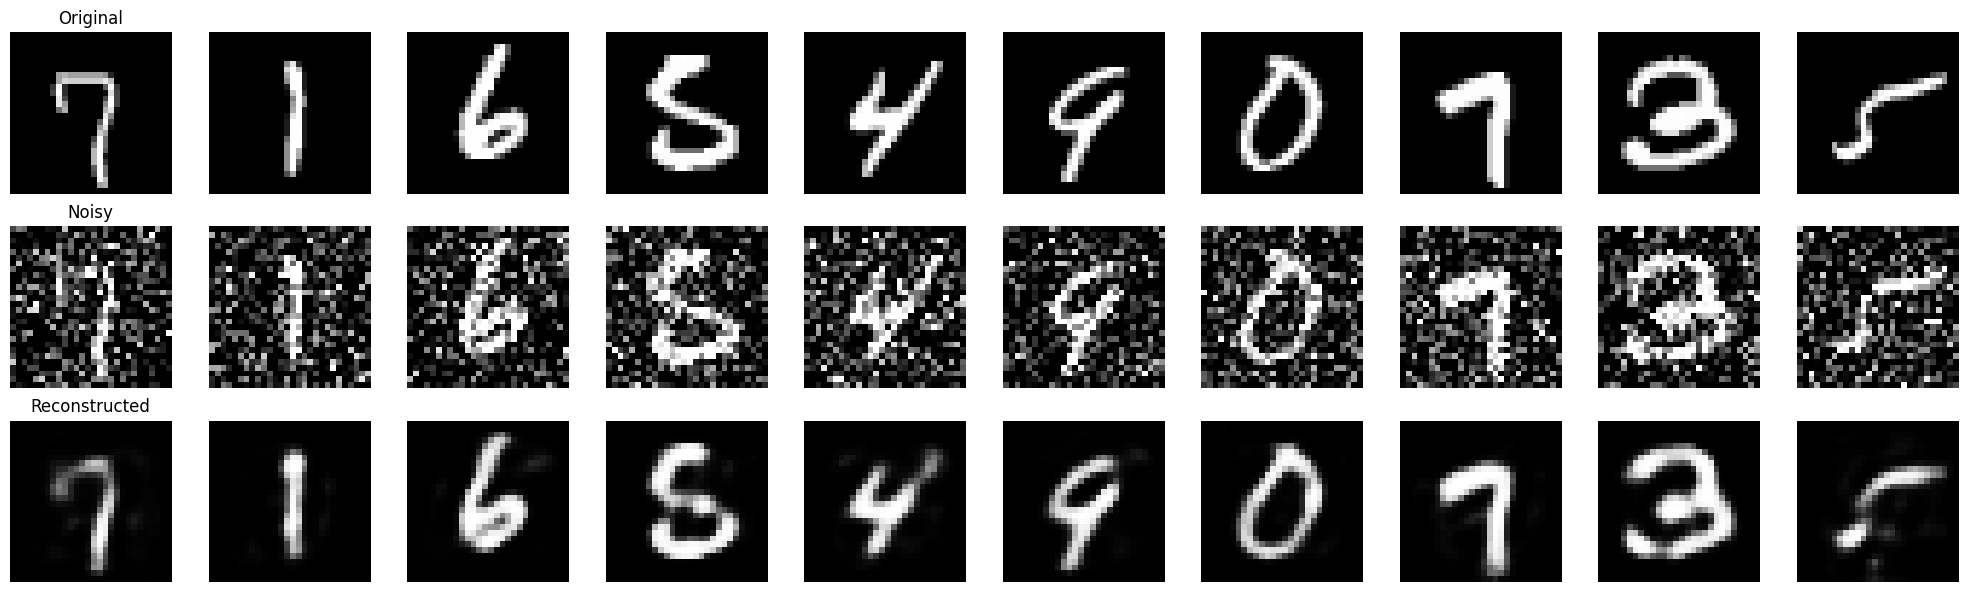

In [45]:
model.eval()

with torch.no_grad():
  # Get a batch of images from the train_loader for evaluation
  dataiter = iter(train_loader)
  images, labels = next(dataiter)

  # Flatten the images and move to device
  images = images.view(-1, 784).to(device)

  # Add noise to the images
  noisy_images = add_noise(images, noise_factor=0.4)

  # Get reconstructed images from the model
  reconstructed_images = model(noisy_images)

  # Calculate evaluation loss
  eval_loss = criterion(reconstructed_images, images).item()
  print(f'Evaluation Loss: {eval_loss:.6f}')

  # Detach images from GPU and convert to CPU for plotting
  images = images.cpu()
  noisy_images = noisy_images.cpu()
  reconstructed_images = reconstructed_images.cpu()

  # Plot original, noisy, and reconstructed images
  fig, axes = plt.subplots(3, 10, figsize=(20, 6))
  for i in range(10):
    # Original Images
    axes[0, i].imshow(images[i].view(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    # Noisy Images
    axes[1, i].imshow(noisy_images[i].view(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Noisy')

    # Reconstructed Images
    axes[2, i].imshow(reconstructed_images[i].view(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title('Reconstructed')

  plt.tight_layout()
  plt.show()